# 🐍 Clase 3 — Visualización, Buenas Prácticas y Taller Integrador
## Python para el Análisis de Datos — ICM-CSIC

---

### Antes de empezar: entorno y repositorio

Esta clase empieza desde cero: nuevo entorno virtual con `uv` y nuevo repositorio Git. Seguimos los pasos juntos.

**1. Crear y activar el entorno con `uv`**

```bash
# En la terminal de VS Code:
uv init .
uv venv

# macOS / Linux:
source .venv/bin/activate

# Windows:
.venv\Scripts\activate

# Instalar paquetes:
uv add pandas numpy matplotlib seaborn plotly jupyter ipykernel
```

**2. Inicializar repositorio Git y vincularlo a GitHub**

```bash
# Si no funciona por la rama, poner: git checkout -b dev en vez de iniciarlo
git init
git add .
git commit -m "Inicio clase 3 - entorno y estructura de proyecto"

# En GitHub: crear repositorio clase3_argo (vacío, sin README)
git remote add origin https://github.com/TU_USUARIO/argo-final.git
git branch -M main
git push -u origin main
```

**3. Seleccionar el kernel correcto en VS Code**

En la esquina superior derecha del notebook → *Select Kernel* → `Python (.venv)`

---

## 📦 Imports y carga de datos

Lo primero siempre: importar todas las librerías y cargar el dataset. Es buena práctica tenerlo todo al principio del notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print("✅ Librerías cargadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías cargadas correctamente
   pandas  3.0.3
   numpy   2.4.4
   seaborn 0.13.2


In [3]:
# Cargamos el dataset Argo — el mismo que trabajamos en la Clase 2
df = pd.read_csv('data/argo_mediterraneo.csv', parse_dates=['date'])

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dataset cargado: 9,000 filas × 9 columnas


,float_id,date,latitude,longitude,depth,pressure,temperature,salinity,basin
0,6903291,2021-01-01 03:15:39,36.2805,24.3338,99.9,102.4,17.548,39.323,Eastern Mediterranean
1,6902874,2021-01-01 05:08:30,34.6341,31.2164,363.2,372.3,14.960,38.608,Eastern Mediterranean
2,6902874,2021-01-01 05:08:30,34.6341,31.2164,390.0,399.8,14.800,38.580,Eastern Mediterranean
3,6902872,2021-01-01 05:08:30,36.1199,20.5688,47.6,48.8,18.518,39.269,Eastern Mediterranean
4,6902872,2021-01-01 05:08:30,36.1199,20.5688,424.6,435.2,15.421,39.149,Eastern Mediterranean


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   float_id     9000 non-null   int64         
 1   date         9000 non-null   datetime64[us]
 2   latitude     9000 non-null   float64       
 3   longitude    9000 non-null   float64       
 4   depth        8122 non-null   float64       
 5   pressure     9000 non-null   float64       
 6   temperature  8095 non-null   float64       
 7   salinity     8124 non-null   float64       
 8   basin        9000 non-null   str           
dtypes: datetime64[us](1), float64(6), int64(1), str(1)
memory usage: 632.9 KB


In [5]:
df.describe()

,float_id,date,latitude,longitude,depth,pressure,temperature,salinity
count,9.000000e+03,9000,9000.000000,9000.000000,8122.000000,9000.000000,8095.000000,8124.000000
mean,6.584349e+06,2022-06-12 14:37:48.915111,38.481104,13.710775,197.626718,202.742750,14.810624,36.429435
min,1.902575e+06,2021-01-01 03:15:39,31.305400,-5.829100,0.500000,0.500000,7.473000,0.000000
25%,6.902803e+06,2021-09-01 22:59:15,35.555875,4.468900,77.100000,79.200000,13.712000,38.216950
50%,6.903015e+06,2022-05-26 11:18:00,38.579950,9.149200,179.400000,184.450000,14.380000,38.602000
75%,6.903245e+06,2023-04-11 02:26:00,41.406925,25.729100,307.375000,314.850000,15.737000,38.958000
max,7.901066e+06,2023-12-30 21:47:40,46.998200,36.989700,487.500000,499.700000,29.648000,39.880000
std,9.761108e+05,NaN,3.580523,11.610061,135.513682,138.513523,2.693474,6.873706


In [6]:
# Limpieza rápida: eliminamos filas con NaN en las columnas clave
df_clean = df.dropna(subset=['temperature', 'salinity', 'depth']).copy()

# Extraemos mes y año para análisis estacionales
df_clean['month'] = df_clean['date'].dt.month
df_clean['year'] = df_clean['date'].dt.year
df_clean['month_name'] = df_clean['date'].dt.strftime('%b')  # Jan, Feb...

print(f"Filas tras limpieza: {df_clean.shape[0]:,} (eliminadas: {df.shape[0] - df_clean.shape[0]:,})")
print(f"Cuencas disponibles: {df_clean['basin'].unique()}")

Filas tras limpieza: 6,579 (eliminadas: 2,421)
Cuencas disponibles: <StringArray>
['Eastern Mediterranean',              'Adriatic', 'Western Mediterranean',
            'Tyrrhenian',              'Ligurian']
Length: 5, dtype: str


---
## 🔢 Bloque F3 — Pandas Avanzado

### `groupby`: agrupar y agregar

`groupby` es una de las operaciones más poderosas de Pandas. Funciona en tres pasos:
1. **Split** — divide el DataFrame según una categoría
2. **Apply** — aplica una función a cada grupo
3. **Combine** — combina los resultados en un nuevo DataFrame

```
df  ─────────────────────►  df.groupby('basin')  ─────►  .mean()
     Western | Eastern |         Western ─────►  media
     Adriatic| ...              Eastern  ─────►  media
                                Adriatic ─────►  media
```

In [7]:
# Temperatura media por cuenca
temp_por_cuenca = df_clean.groupby('basin')['temperature'].mean().round(2)
print("Temperatura media (°C) por cuenca:")
print(temp_por_cuenca.sort_values(ascending=False))

Temperatura media (°C) por cuenca:
basin
Adriatic                 15.24
Tyrrhenian               15.03
Eastern Mediterranean    14.98
Western Mediterranean    14.75
Ligurian                 14.12
Name: temperature, dtype: float64


In [8]:
type(temp_por_cuenca)

pandas.Series

In [9]:
# Múltiples estadísticas a la vez con .agg()
stats_cuenca = df_clean.groupby('basin').agg(
    temp_media=('temperature', 'mean'),
    temp_std=('temperature', 'std'),
    sal_media=('salinity', 'mean'),
    n_mediciones=('temperature', 'count')
).round(2)

print("Estadísticas por cuenca:")
stats_cuenca

Estadísticas por cuenca:


,temp_media,temp_std,sal_media,n_mediciones
basin,,,,
Adriatic,15.24,1.81,38.86,218
Eastern Mediterranean,14.98,3.54,34.62,2020
Ligurian,14.12,1.18,38.53,181
Tyrrhenian,15.03,1.95,38.14,278
Western Mediterranean,14.75,2.30,37.11,3882


In [10]:
type(stats_cuenca)

pandas.DataFrame

In [11]:
# Temperatura media mensual (variación estacional)
temp_mensual = (
    df_clean[df_clean['depth'] <= 10]  # Solo superficie
    .groupby('month')['temperature']
    .mean()
    .round(2)
    .reset_index()
)

print("Temperatura superficial media por mes:")
print(temp_mensual.to_string(index=False))

Temperatura superficial media por mes:
 month  temperature
     1        16.55
     2        14.36
     3        13.88
     4        15.39
     5        18.21
     6        21.03
     7        25.66
     8        25.47
     9        24.75
    10        21.62
    11        18.52
    12        16.39


### Pivot tables

Una **pivot table** reorganiza los datos para mostrar una variable en función de dos categorías. Es el equivalente de las tablas dinámicas de Excel.

```
           | Western | Eastern | Adriatic
    -------+---------+---------+---------
    Jan    |  14.2   |  15.1   |  13.8
    Feb    |  13.9   |  14.7   |  12.5
    ...    |  ...    |  ...    |  ...
```

In [12]:
# Tabla pivot: temperatura media por mes y cuenca
pivot_temp = pd.pivot_table(
    df_clean[df_clean['depth'] <= 10],
    values='temperature',
    index='month',
    columns='basin',
    aggfunc='mean'
).round(1)

print("Temperatura media superficial (°C) por mes y cuenca:")
pivot_temp

Temperatura media superficial (°C) por mes y cuenca:


basin,Adriatic,Eastern Mediterranean,Ligurian,Tyrrhenian,Western Mediterranean
month,,,,,
1,15.9,17.9,NaN,15.0,15.4
2,NaN,14.3,NaN,14.6,14.4
3,NaN,12.7,NaN,14.6,15.1
4,16.1,13.9,NaN,NaN,16.1
5,NaN,20.1,NaN,NaN,17.8
6,20.0,18.9,21.8,23.9,22.0
7,24.5,25.5,NaN,25.6,25.9
8,27.0,26.4,NaN,NaN,25.2
9,NaN,26.2,NaN,NaN,23.7


In [13]:
type(pivot_temp)

pandas.DataFrame

In [14]:
df_clean[(df_clean['basin'] == "Ligurian") & (df_clean['month']==1)]

,float_id,date,latitude,longitude,depth,pressure,temperature,salinity,basin,month,year,month_name
144,3901849,2021-01-16 12:02:20,44.0353,9.2092,24.6,25.2,14.536,38.060,Ligurian,1,2021,Jan
6275,6904239,2023-01-20 22:48:40,42.8816,8.1593,231.2,237.0,13.837,38.655,Ligurian,1,2023,Jan
6276,6904239,2023-01-20 22:48:40,42.8816,8.1593,344.5,353.1,13.812,38.681,Ligurian,1,2023,Jan


### 🤖 Ejercicio 1 — Pandas Avanzado con Copilot

**Enunciado:** Calcula la salinidad media y desviación estándar por cuenca, pero únicamente para mediciones en superficie (depth ≤ 10 m). Ordena el resultado de mayor a menor salinidad media.

**💡 Prompt sugerido para Copilot:**
> *"Tengo un DataFrame de Pandas llamado `df_clean` con columnas `salinity`, `depth` y `basin`. Necesito filtrar las filas donde `depth <= 10`, luego agrupar por `basin` y calcular la media y desviación estándar de `salinity`. Quiero el resultado ordenado de mayor a menor media. Muéstrame el código."*

In [15]:
# Tu solución aquí:
# Filtrar datos superficiales (depth <= 10 m)
df_surface = df_clean[df_clean["depth"] <= 10]

# Agrupar por cuenca y calcular estadísticas de salinidad
resumen_salinidad = (
    df_surface
    .groupby("basin")["salinity"]
    .agg(["mean", "std"])
    .sort_values(by="mean", ascending=False)
)

# Renombrar columnas para mayor claridad
resumen_salinidad = resumen_salinidad.rename(
    columns={
        "mean": "salinity_mean",
        "std": "salinity_std"
    }
)

# Mostrar resultado
print(resumen_salinidad)

                       salinity_mean  salinity_std
basin                                             
Adriatic                   38.819083      0.463935
Ligurian                   38.281000      0.052288
Tyrrhenian                 37.929182      0.467037
Western Mediterranean      35.974139      5.837470
Eastern Mediterranean      31.867864     10.355245


In [16]:
# SOLUCIÓN:
sal_superficie = (
    df_clean[df_clean['depth'] <= 10]
    .groupby('basin')
    .agg(sal_media=('salinity', 'mean'), sal_std=('salinity', 'std'))
    .round(3)
    .sort_values('sal_media', ascending=False)
)
sal_superficie

,sal_media,sal_std
basin,,
Adriatic,38.819,0.464
Ligurian,38.281,0.052
Tyrrhenian,37.929,0.467
Western Mediterranean,35.974,5.837
Eastern Mediterranean,31.868,10.355


---
## 🎨 Bloque G1 — Matplotlib y Seaborn

### Anatomía de una figura en Matplotlib

```
 Figure (lienzo total)
 ┌──────────────────────────────┐
 │  Axes (área de dibujo)       │
 │  ┌────────────────────────┐  │
 │  │  Title                 │  │
 │  │                        │  │
 │  │   ·  · ·               │  │  ← líneas, puntos, barras...
 │  │  ·    ·  ·             │  │
 │  │                        │  │
 │  │  xlabel                │  │
 │  └────────────────────────┘  │
 └──────────────────────────────┘
```

El patrón `fig, ax = plt.subplots()` es el más versátil y el que usaremos siempre.

In [17]:
# Configuración global de estilo para toda la sesión
sns.set_theme(style='whitegrid', palette='colorblind')  # paleta apta para daltonismo
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Estilo configurado")

✅ Estilo configurado


### Gráfico 1: Serie temporal de temperatura superficial

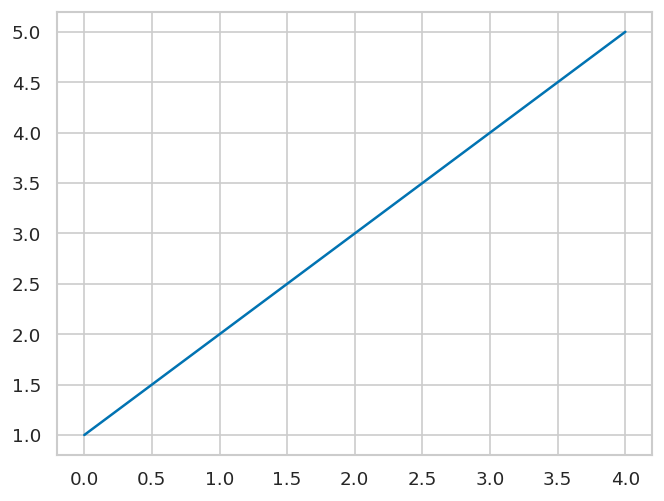

In [18]:
x = [1, 2, 3, 4, 5]
plt.plot(x)

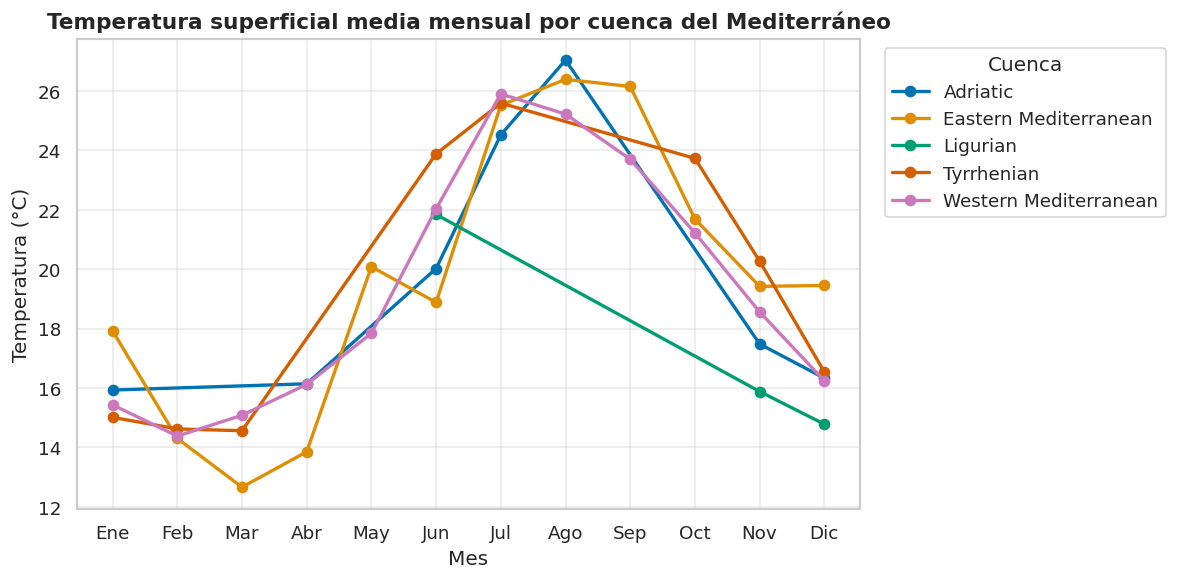

✅ Figura guardada como temperatura_mensual.png


In [19]:
# Preparamos datos: temperatura superficial media mensual por cuenca
superficie = df_clean[df_clean['depth'] <= 10].copy()
temp_serie = (
    superficie.groupby(['month', 'basin'])['temperature']
    .mean().round(2)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

for basin, grupo in temp_serie.groupby('basin'):
    ax.plot(grupo['month'], grupo['temperature'], marker='o', linewidth=2, label=basin)

ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Temperatura (°C)', fontsize=12)
ax.set_title('Temperatura superficial media mensual por cuenca del Mediterráneo', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.legend(title='Cuenca', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('temperatura_mensual.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada como temperatura_mensual.png")

### Gráfico 2: Diagrama T-S (Temperatura–Salinidad)

El **diagrama T-S** es uno de los gráficos más clásicos en oceanografía. Cada punto representa una medición a una profundidad dada. La posición en el diagrama permite identificar masas de agua de diferente origen.

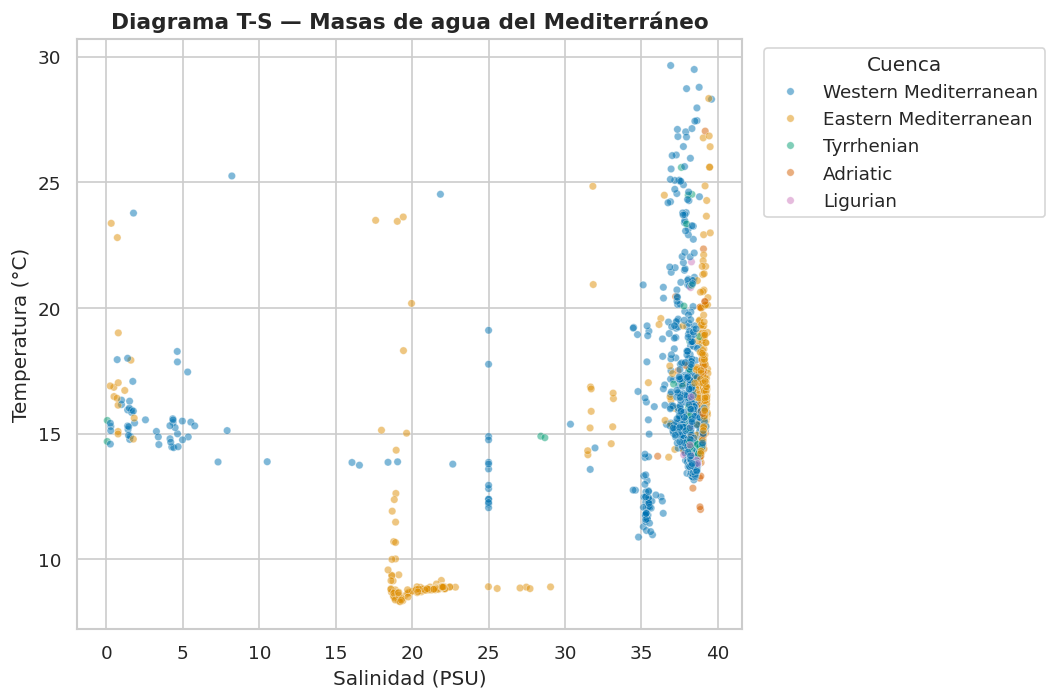

In [20]:
# Diagrama T-S con Seaborn: temperatura vs salinidad, coloreado por cuenca
# Usamos una muestra para que el gráfico no sea demasiado denso
muestra = df_clean.sample(n=min(3000, len(df_clean)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=muestra,
    x='salinity',
    y='temperature',
    hue='basin',
    alpha=0.5,
    s=20,
    ax=ax
)

ax.set_xlabel('Salinidad (PSU)', fontsize=12)
ax.set_ylabel('Temperatura (°C)', fontsize=12)
ax.set_title('Diagrama T-S — Masas de agua del Mediterráneo', fontsize=13, fontweight='bold')
ax.legend(title='Cuenca', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('diagrama_TS.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráfico 3: Distribución de temperatura por cuenca (violin + boxplot)

C:\Users\diama\AppData\Local\Temp\ipykernel_16916\3554016744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\diama\AppData\Local\Temp\ipykernel_16916\3554016744.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


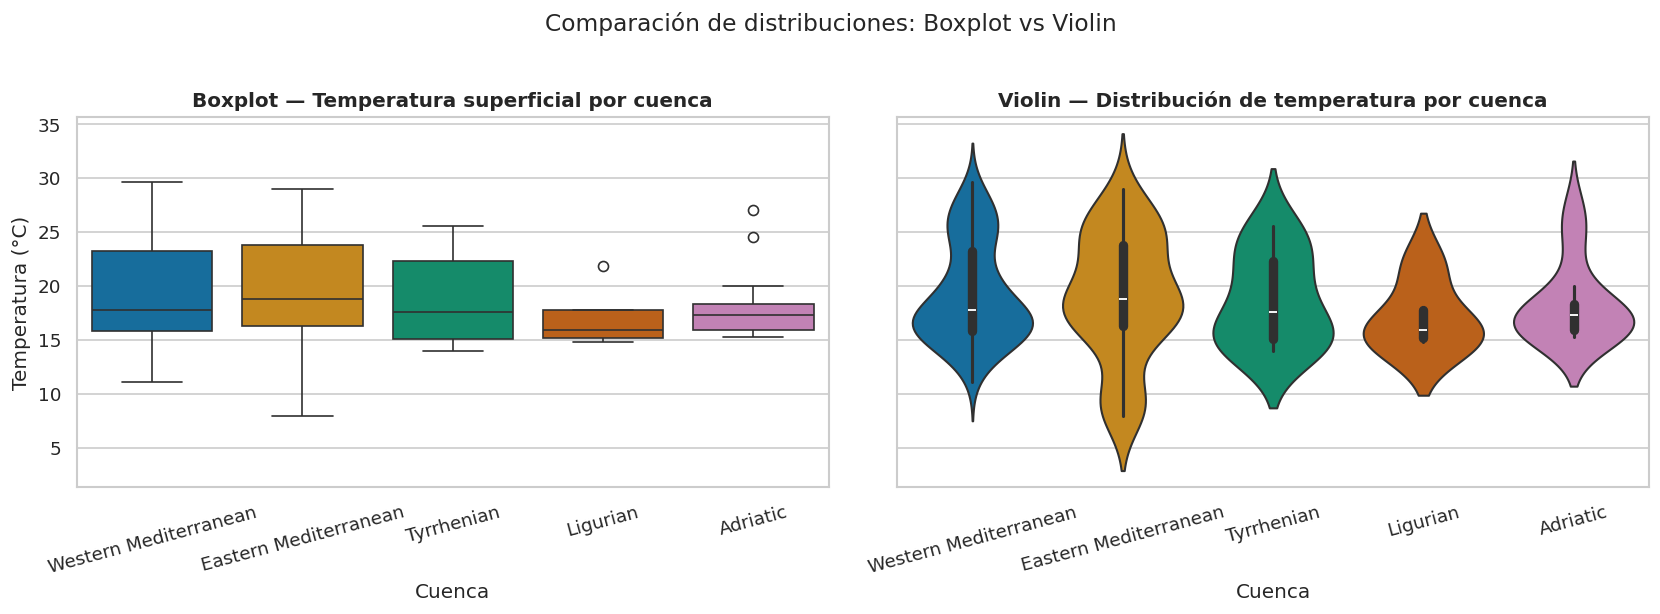

In [21]:
# Violin + boxplot: muestra la distribución Y la mediana y cuartiles a la vez
fig, axes = plt.subplots(1, 2, sharey= True, figsize=(14, 5))

# Panel izquierdo: boxplot clásico
sns.boxplot(
    data=df_clean[df_clean['depth'] <= 10],
    x='basin',
    y='temperature',
    palette='colorblind',
    ax=axes[0]
)
axes[0].set_title('Boxplot — Temperatura superficial por cuenca', fontweight='bold')
axes[0].set_xlabel('Cuenca')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].tick_params(axis='x', rotation=15)

# Panel derecho: violin (muestra toda la distribución)
sns.violinplot(
    data=df_clean[df_clean['depth'] <= 10],
    x='basin',
    y='temperature',
    palette='colorblind',
    ax=axes[1]
)
axes[1].set_title('Violin — Distribución de temperatura por cuenca', fontweight='bold')
axes[1].set_xlabel('Cuenca')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparación de distribuciones: Boxplot vs Violin', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('distribucion_temperatura.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráfico 4: Heatmap de temperatura mensual por cuenca

In [22]:
pivot_temp

basin,Adriatic,Eastern Mediterranean,Ligurian,Tyrrhenian,Western Mediterranean
month,,,,,
1,15.9,17.9,NaN,15.0,15.4
2,NaN,14.3,NaN,14.6,14.4
3,NaN,12.7,NaN,14.6,15.1
4,16.1,13.9,NaN,NaN,16.1
5,NaN,20.1,NaN,NaN,17.8
6,20.0,18.9,21.8,23.9,22.0
7,24.5,25.5,NaN,25.6,25.9
8,27.0,26.4,NaN,NaN,25.2
9,NaN,26.2,NaN,NaN,23.7


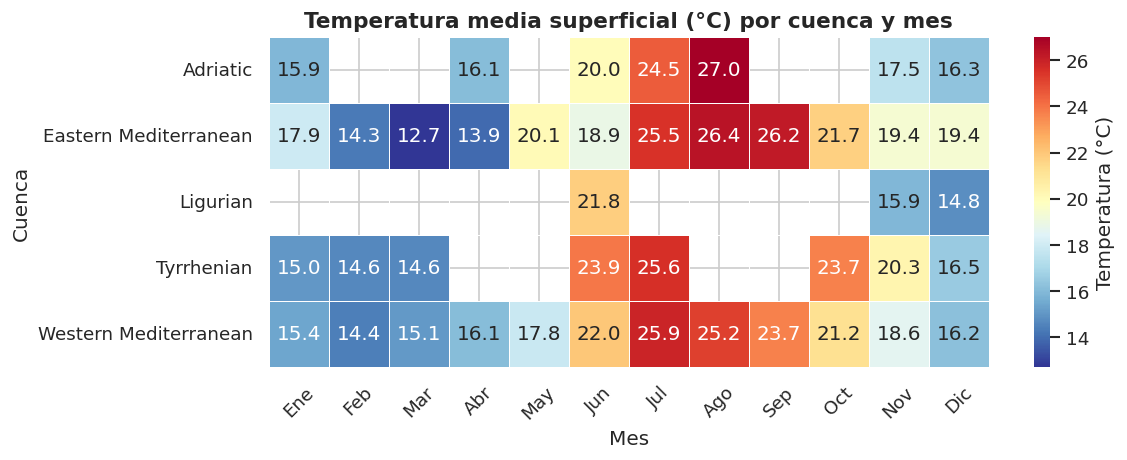

In [23]:
# Heatmap construido a partir de la pivot table que calculamos antes
fig, ax = plt.subplots(figsize=(10, 4))

sns.heatmap(
    pivot_temp.T,           # Transponemos: cuencas en filas, meses en columnas
    cmap='RdYlBu_r',       # Rojo=caliente, Azul=frío
    annot=True,             # Mostrar valores numéricos
    fmt='.1f',              # 1 decimal
    linewidths=0.5,
    cbar_kws={'label': 'Temperatura (°C)'},
    ax=ax
)

ax.set_title('Temperatura media superficial (°C) por cuenca y mes', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Cuenca')
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=45)

plt.tight_layout()
plt.savefig('heatmap_temperatura.png', dpi=300, bbox_inches='tight')
plt.show()

### Gráfico 5: Perfil vertical de temperatura

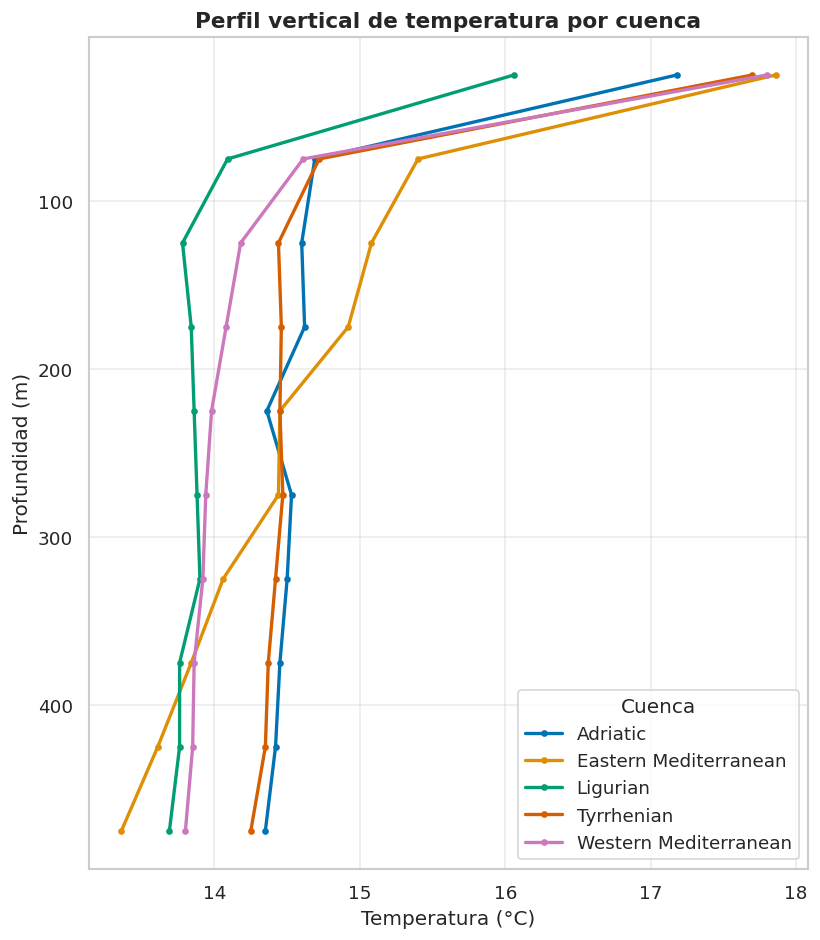

In [24]:
# Perfil vertical: temperatura media a cada profundidad, por cuenca
# Agrupamos por bins de profundidad para suavizar
df_clean['depth_bin'] = pd.cut(df_clean['depth'], bins=range(0, 2001, 50), labels=range(25, 2001, 50))
df_clean['depth_bin'] = df_clean['depth_bin'].astype(float)

perfil = (
    df_clean.groupby(['depth_bin', 'basin'])['temperature']
    .mean().round(2)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 8))

for basin, grupo in perfil.groupby('basin'):
    grupo_sorted = grupo.sort_values('depth_bin')
    ax.plot(grupo_sorted['temperature'], grupo_sorted['depth_bin'], marker='.', linewidth=2, label=basin)

ax.invert_yaxis()  # ¡Profundidad crece hacia abajo!
ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Profundidad (m)', fontsize=12)
ax.set_title('Perfil vertical de temperatura por cuenca', fontsize=13, fontweight='bold')
ax.legend(title='Cuenca')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('perfil_vertical.png', dpi=300, bbox_inches='tight')
plt.show()

### 🌐 Galería de Seaborn y Matplotlib

¿Buscas inspiración para el tipo de gráfico más adecuado? Estas galerías son tu punto de partida:

- **Seaborn**: https://seaborn.pydata.org/examples/index.html
- **Matplotlib**: https://matplotlib.org/stable/gallery/index.html

**💡 Tip para Copilot:**
> *"Describe el gráfico que quieres en lenguaje natural y pide el código:"*
> 
> *"Con Seaborn, quiero un gráfico de dispersión de temperatura vs salinidad con una línea de regresión, coloreado por cuenca. El eje x es salinidad (37-39 PSU) y el eje y temperatura (10-30°C). Usa el DataFrame `df_clean`."*

### 🤖 Ejercicio 2 — Visualización con Seaborn

**Enunciado:** Crea un gráfico de barras que muestre el **número de mediciones por mes** (columna `month`) para el dataset completo (`df_clean`). El eje x son los meses (1-12), el eje y el número de mediciones. Añade un título descriptivo y etiquetas a los ejes.

**💡 Prompt para Copilot:**
> *"Con Seaborn, quiero un countplot (gráfico de barras de conteo) que muestre cuántas filas hay por cada mes en el DataFrame `df_clean`. La columna del mes se llama `month`. Quiero los meses como etiquetas en el eje x, título y etiquetas de ejes en español."*

C:\Users\diama\AppData\Local\Temp\ipykernel_16916\4213006737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


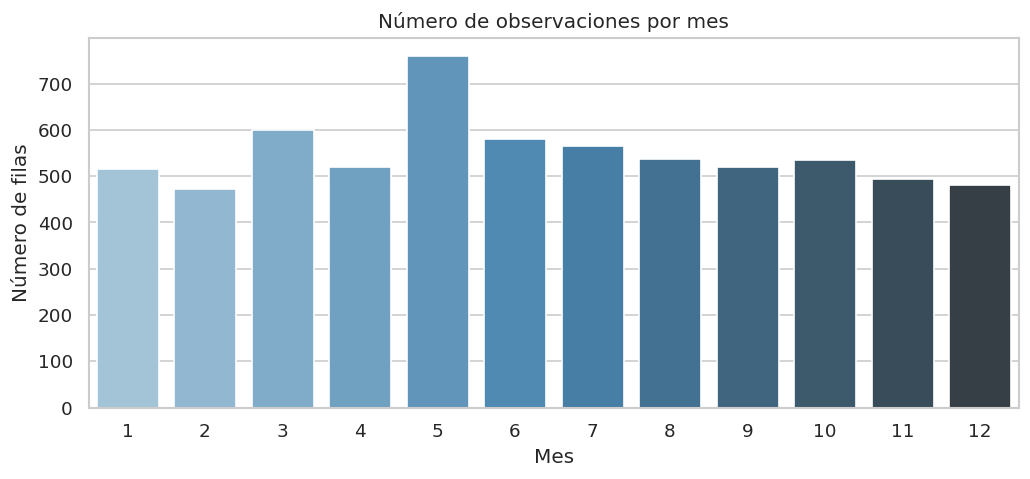

In [25]:
# Tu solución aquí:
# Crear figura
plt.figure(figsize=(10, 4))

# Countplot por mes
sns.countplot(
    data=df_clean,
    x="month",
    order=sorted(df_clean["month"].unique()),
    palette='Blues_d'
)

# Título y etiquetas
plt.title("Número de observaciones por mes")
plt.xlabel("Mes")
plt.ylabel("Número de filas")

# Mostrar gráfico
plt.show()

C:\Users\diama\AppData\Local\Temp\ipykernel_16916\2943339438.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='month', palette='Blues_d', ax=ax)
C:\Users\diama\AppData\Local\Temp\ipykernel_16916\2943339438.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])


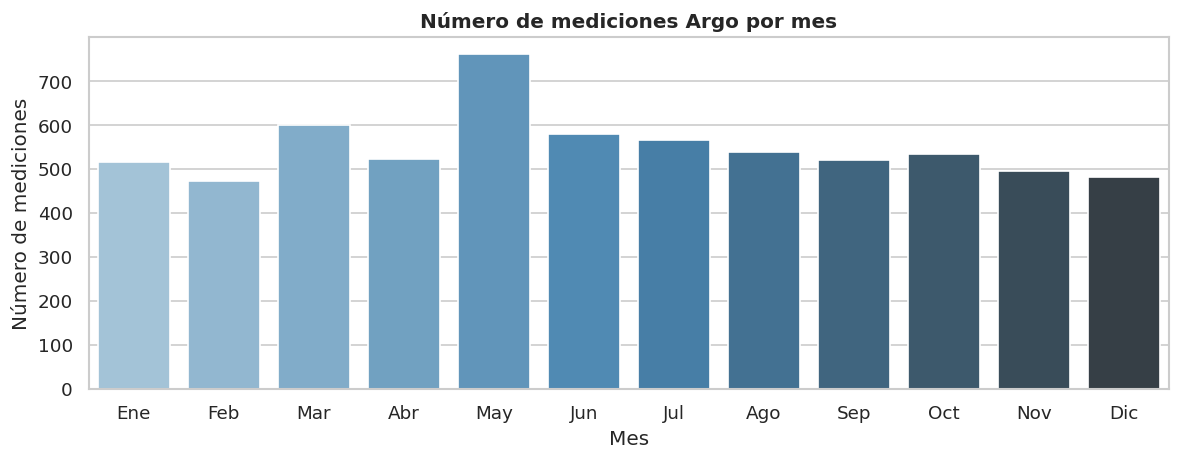

In [26]:
# SOLUCIÓN:
fig, ax = plt.subplots(figsize=(10, 4))
sns.countplot(data=df_clean, x='month', palette='Blues_d', ax=ax)
ax.set_title('Número de mediciones Argo por mes', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de mediciones')
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

---
## 🌍 Bloque G2 — Plotly: Visualizaciones Interactivas

Plotly genera gráficos **interactivos**: zoom, hover con información, filtros por categoría... Ideales para exploración de datos y presentaciones dinámicas.

```
Matplotlib / Seaborn  →  Figuras para publicación (PNG, PDF, SVG)
Plotly                →  Exploración interactiva, dashboards, HTML
```

**Galería de Plotly Express**: https://plotly.com/python/plotly-express/

### Gráfico interactivo 1: Diagrama T-S con Plotly

In [27]:
# Diagrama T-S interactivo
# Hover: muestra fecha, ID de boya y profundidad al pasar el ratón
muestra_plotly = df_clean.sample(n=min(2000, len(df_clean)), random_state=42)

fig_ts = px.scatter(
    muestra_plotly,
    x='salinity',
    y='temperature',
    color='basin',
    opacity=0.6,
    hover_data=['date', 'float_id', 'depth'],
    title='Diagrama T-S interactivo — Mediterráneo',
    labels={
        'salinity': 'Salinidad (PSU)',
        'temperature': 'Temperatura (°C)',
        'basin': 'Cuenca'
    }
)

fig_ts.update_layout(height=500)
fig_ts.show()

### Gráfico interactivo 2: Serie temporal con zoom

In [28]:
# Serie temporal: temperatura superficial agregada por semana
superficie_ts = (
    df_clean[df_clean['depth'] <= 10]
    .set_index('date')
    .groupby(['basin', pd.Grouper(freq='ME')])['temperature']  # mensual
    .mean()
    .round(2)
    .reset_index()
)

fig_time = px.line(
    superficie_ts,
    x='date',
    y='temperature',
    color='basin',
    markers=True,
    title='Serie temporal de temperatura superficial — Mediterráneo',
    labels={
        'date': 'Fecha',
        'temperature': 'Temperatura (°C)',
        'basin': 'Cuenca'
    }
)

# Añadimos selector de rango temporal (botones de zoom)
fig_time.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=[
            dict(count=6, label="6M", step="month"),
            dict(count=1, label="1A", step="year"),
            dict(step="all", label="Todo")
        ]
    )
)

fig_time.update_layout(height=500)
fig_time.show()

### Gráfico interactivo 3: Mapa de distribución de boyas Argo ⭐

In [29]:
# Mapa interactivo: posición de las boyas coloreadas por temperatura superficial
mapa_data = (
    df_clean[df_clean['depth'] <= 10]
    .groupby('float_id')
    .agg(
        latitude=('latitude', 'mean'),
        longitude=('longitude', 'mean'),
        temperature=('temperature', 'mean'),
        salinity=('salinity', 'mean'),
        basin=('basin', 'first'),
        n_mediciones=('temperature', 'count')
    )
    .round(3)
    .reset_index()
)

fig_map = px.scatter_geo(
    mapa_data,
    lat='latitude',
    lon='longitude',
    color='temperature',
    size='n_mediciones',
    hover_name='float_id',
    hover_data={
        'latitude': ':.2f',
        'longitude': ':.2f',
        'temperature': ':.1f',
        'salinity': ':.2f',
        'basin': True
    },
    color_continuous_scale='RdYlBu_r',
    title='Distribución geográfica de boyas Argo en el Mediterráneo',
    labels={'temperature': 'Temp. media (°C)', 'n_mediciones': 'N mediciones'}
)

fig_map.update_geos(
    scope='europe',
    showland=True, landcolor='#e8e8e8',
    showocean=True, oceancolor='#d0e4f0',
    showcoastlines=True, coastlinecolor='#888888',
    center=dict(lat=38, lon=15),
    projection_scale=4
)



fig_map.update_layout(height=550, coloraxis_colorbar_title='Temp (°C)')
fig_map.show()

In [30]:
# Guardar el mapa como HTML interactivo
fig_map.write_html('mapa_argo_interactivo.html')
print("✅ Mapa guardado como mapa_argo_interactivo.html")
print("   Puedes abrirlo en cualquier navegador y compartirlo.")

✅ Mapa guardado como mapa_argo_interactivo.html
   Puedes abrirlo en cualquier navegador y compartirlo.


### Gráfico interactivo 4: Boxplot animado por cuenca

In [31]:
# Box plot interactivo: temperatura por cuenca, con opción de filtrar clicando en la leyenda
fig_box = px.box(
    df_clean[df_clean['depth'] <= 10],
    x='basin',
    y='temperature',
    color='basin',
    points='outliers',
    title='Distribución de temperatura superficial por cuenca (interactivo)',
    labels={'basin': 'Cuenca', 'temperature': 'Temperatura (°C)'}
)

fig_box.update_layout(height=450, showlegend=False)
fig_box.show()

### 🤖 Ejercicio 3 — Mapa de salinidad con Plotly

**Enunciado:** Crea un mapa similar al de temperatura, pero mostrando la **salinidad media** de cada boya. Cambia el título y la escala de colores (prueba `'Blues'` o `'Viridis'`). Guárdalo como `mapa_salinidad.html`.

**💡 Prompt para Copilot:**
> *"Tengo un DataFrame `mapa_data` con columnas `latitude`, `longitude`, `salinity`, `basin` y `float_id`. Quiero un `px.scatter_geo` centrado en el Mediterráneo que muestre la salinidad media de cada boya. Usa la paleta de colores `Blues`. Guarda el resultado como HTML."*

In [34]:
# Tu solución aquí:
# Calcular salinidad media por boya (float_id) para el mapa
df_map = (
    mapa_data
    .groupby("float_id", as_index=False)
    .agg({
        "latitude": "mean",
        "longitude": "mean",
        "salinity": "mean",
        "basin": "first"
    })
)


# Crear figura de mapa con Plotly Express
fig = px.scatter_geo(
    df_map,
    lat="latitude",
    lon="longitude",
    color="salinity",
    hover_name="float_id",
    hover_data={
        "salinity": ":.2f",
        "basin": True,
        "latitude": False,
        "longitude": False
    },
    projection="natural earth",
    color_continuous_scale="Blues",
    title="Salinidad media por boya en el Mediterráneo"
)

# Centrar mapa en el Mediterráneo
fig.update_geos(
    center={"lat": 37.5, "lon": 15},
    lataxis_range=[30, 46],
    lonaxis_range=[-6, 36],
    showland=True,
    landcolor="lightgray"
)

# Guardar figura interactiva como HTML
fig.write_html("salinidad_mediterraneo.html")
fig.show()

In [33]:
# SOLUCIÓN:
fig_sal_map = px.scatter_geo(
    mapa_data,
    lat='latitude', lon='longitude',
    color='salinity',
    hover_name='float_id',
    hover_data={'salinity': ':.2f', 'basin': True},
    color_continuous_scale='Blues',
    title='Salinidad media de boyas Argo en el Mediterráneo'
)
fig_sal_map.update_geos(
    scope='europe', showland=True, landcolor='#e8e8e8',
    center=dict(lat=38, lon=15), projection_scale=4
)
fig_sal_map.write_html('mapa_salinidad.html')
fig_sal_map.show()
print("✅ Guardado mapa_salinidad.html")

✅ Guardado mapa_salinidad.html


---
## 🧹 Bloque H — Buenas Prácticas de Código

### PEP 8: el estándar de estilo de Python

PEP 8 define cómo debe verse el código Python para que sea legible por cualquier persona. Aquí los puntos más importantes:

In [35]:
# ❌ ANTES: código difícil de leer
def calcTemp(t,s,p,cuenca):
    resultado=t*1.0+(s-38)*0.05
    if cuenca=="Western Mediterranean": resultado=resultado-0.2
    return resultado

# ✅ DESPUÉS: código limpio según PEP 8
def calcular_temperatura_corregida(temperatura, salinidad, presion, cuenca):
    """Aplica una corrección empírica a la temperatura según salinidad y cuenca."""
    CORRECCION_OCCIDENTAL = 0.2
    temperatura_corregida = temperatura + (salinidad - 38) * 0.05
    if cuenca == "Western Mediterranean":
        temperatura_corregida -= CORRECCION_OCCIDENTAL
    return temperatura_corregida

print("Ejemplo: temperatura corregida =",
      calcular_temperatura_corregida(20.5, 38.1, 100, "Western Mediterranean"))

Ejemplo: temperatura corregida = 20.305


### Docstrings

Un docstring bien escrito permite que tanto tus colegas como Copilot entiendan qué hace una función sin leer el código.

In [36]:
def limpiar_dataset_argo(df, columnas_clave=None, profundidad_maxima=2000):
    """
    Limpia un DataFrame de datos Argo eliminando valores nulos y outliers básicos.

    Args:
        df (pd.DataFrame): DataFrame con columnas estándar del dataset Argo.
        columnas_clave (list, optional): Columnas donde se eliminan filas con NaN.
            Por defecto: ['temperature', 'salinity', 'depth'].
        profundidad_maxima (float): Profundidad máxima permitida en metros. Default: 2000.

    Returns:
        pd.DataFrame: DataFrame limpio con filas válidas.

    Example:
        >>> df_limpio = limpiar_dataset_argo(df)
        >>> print(df_limpio.shape)
    """
    if columnas_clave is None:
        columnas_clave = ['temperature', 'salinity', 'depth']

    df_limpio = df.dropna(subset=columnas_clave).copy()
    df_limpio = df_limpio[df_limpio['depth'] <= profundidad_maxima]

    return df_limpio


# Probar la función:
help(limpiar_dataset_argo)

Help on function limpiar_dataset_argo in module __main__:

limpiar_dataset_argo(df, columnas_clave=None, profundidad_maxima=2000)
    Limpia un DataFrame de datos Argo eliminando valores nulos y outliers básicos.
    
    Args:
        df (pd.DataFrame): DataFrame con columnas estándar del dataset Argo.
        columnas_clave (list, optional): Columnas donde se eliminan filas con NaN.
            Por defecto: ['temperature', 'salinity', 'depth'].
        profundidad_maxima (float): Profundidad máxima permitida en metros. Default: 2000.
    
    Returns:
        pd.DataFrame: DataFrame limpio con filas válidas.
    
    Example:
        >>> df_limpio = limpiar_dataset_argo(df)
        >>> print(df_limpio.shape)



In [37]:
def calcular_temperatura_corregida(temperatura, salinidad, presion, cuenca):
    """
    Calcula la temperatura corregida del agua de mar en función de la salinidad
    y de la cuenca oceánica.

    La corrección aplica:
    - Un ajuste lineal en función de la desviación de la salinidad respecto
      a un valor de referencia (38 PSU).
    - Una corrección adicional fija para la cuenca del Mediterráneo Occidental.

    Parámetros
    ----------
    temperatura : float
        Temperatura original del agua (°C).
    salinidad : float
        Salinidad del agua (PSU).
    presion : float
        Presión (dbar). Actualmente no se utiliza en el cálculo,
        pero se mantiene por compatibilidad futura.
    cuenca : str
        Nombre de la cuenca oceánica (por ejemplo, "Western Mediterranean").

    Retorna
    -------
    float
        Temperatura corregida (°C).

    Notas
    -----
    - La corrección por salinidad se calcula como:
        (salinidad - 38) * 0.05
    - Para la cuenca "Western Mediterranean" se resta una
      corrección adicional constante de 0.2 °C.
    """

    CORRECCION_OCCIDENTAL = 0.2
    temperatura_corregida = temperatura + (salinidad - 38) * 0.05

    if cuenca == "Western Mediterranean":
        temperatura_corregida -= CORRECCION_OCCIDENTAL

    return temperatura_corregida


### Logging: la alternativa profesional a `print()`

In [ ]:
import logging

# Configuración básica del logger
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S'
)

logger = logging.getLogger(__name__)

# ❌ Antes: print() por todas partes
# print(f"Cargando datos... {df.shape[0]} filas")
# print("ERROR: no se encontró el archivo")

# ✅ Después: logging con niveles
logger.info(f"Dataset cargado: {df.shape[0]:,} filas")
logger.info(f"Tras limpieza: {df_clean.shape[0]:,} filas")
logger.warning("Se encontraron valores fuera del rango esperado de salinidad")
# logger.error("No se pudo guardar el archivo — comprobar permisos")

### El bloque `if __name__ == '__main__':`

In [ ]:
# Este patrón es fundamental en cualquier script .py
# Permite que el script se pueda importar como módulo SIN ejecutarlo

# En un notebook lo simulamos así:
def main():
    """Función principal que orquesta el análisis completo."""
    logger.info("Iniciando análisis Argo...")
    
    # Paso 1: carga
    datos = pd.read_csv('data/argo_mediterraneo.csv', parse_dates=['date'])
    logger.info(f"Datos cargados: {datos.shape}")
    
    # Paso 2: limpieza
    datos_limpios = limpiar_dataset_argo(datos)
    logger.info(f"Datos limpios: {datos_limpios.shape}")
    
    # Paso 3: análisis
    estadisticas = datos_limpios.groupby('basin')['temperature'].describe()
    logger.info("Estadísticas calculadas")
    
    return estadisticas


# En un script .py, esto sería:
# if __name__ == '__main__':
#     main()

# En el notebook, simplemente llamamos a main():
resultado = main()
resultado

### 🤖 Ejercicio 4 — Documentar con Copilot

**Enunciado:** La función de abajo está mal documentada. Pide a Copilot que añada un docstring completo en formato Google (con `Args:`, `Returns:` y `Example:`).

**💡 Prompt para Copilot:**
> *"Añade un docstring completo en formato Google a esta función Python. Incluye descripción, Args, Returns y un Example de uso:"*
> *(pega la función a continuación del prompt)*

In [ ]:
# Función sin documentar — añade el docstring con Copilot:
def calcular_densidad_aproximada(temperatura, salinidad):
    rho_0 = 1025.0
    alpha = 0.2
    beta = 0.8
    return rho_0 - alpha * (temperatura - 10) + beta * (salinidad - 35)

# Tu versión documentada aquí:


In [ ]:
# SOLUCIÓN:
def calcular_densidad_aproximada(temperatura, salinidad):
    """
    Calcula una aproximación lineal de la densidad del agua de mar.

    Usa una ecuación linealizada basada en la densidad de referencia del agua
    de mar (1025 kg/m³), con coeficientes de expansión térmica y halina.

    Args:
        temperatura (float): Temperatura del agua en grados Celsius.
        salinidad (float): Salinidad en PSU (Practical Salinity Units).

    Returns:
        float: Densidad aproximada en kg/m³.

    Example:
        >>> calcular_densidad_aproximada(20.0, 38.0)
        1025.4
    """
    rho_0 = 1025.0    # Densidad de referencia (kg/m³)
    alpha = 0.2       # Coeficiente de expansión térmica (kg/m³/°C)
    beta = 0.8        # Coeficiente halino (kg/m³/PSU)
    return rho_0 - alpha * (temperatura - 10) + beta * (salinidad - 35)

print(f"Densidad aproximada: {calcular_densidad_aproximada(20.0, 38.0):.2f} kg/m³")

---
## 🏆 Taller Integrador — `analisis_argo_final.py`

### Objetivo

Vamos a crear juntos, con ayuda de Copilot, un script Python completo que:
1. Carga y limpia el dataset Argo
2. Calcula estadísticas descriptivas por cuenca y por mes
3. Genera tres visualizaciones y las guarda
4. Exporta un CSV con los resultados
5. Aplica logging y buenas prácticas (PEP 8, docstrings, `if __name__`)

### Proceso con Copilot

**Paso 1 — Prompt inicial:** Describe el script completo en lenguaje natural

```
Escribe un script Python llamado analisis_argo_final.py que haga lo siguiente:
1. Cargue el archivo data/argo_mediterraneo.csv con Pandas (columna date como fecha)
2. Limpie los NaN en las columnas temperature, salinity y depth
3. Calcule estadísticas (media, std, min, max) de temperatura y salinidad por cuenca
4. Genere y guarde tres visualizaciones:
   a) Un heatmap de temperatura mensual por cuenca (Seaborn, guardado como PNG)
   b) Un diagrama T-S coloreado por cuenca (Matplotlib, guardado como PNG)
   c) Un mapa interactivo de distribución de boyas (Plotly, guardado como HTML)
5. Exporte las estadísticas a estadisticas_argo.csv
El script debe usar logging (no print), tener funciones bien documentadas con docstrings,
constantes para las rutas de archivo al inicio, y el bloque if __name__ == '__main__'.
```

**Paso 2:** Revisa el código generado. ¿Hace lo que esperabas?

**Paso 3:** Ejecuta desde la terminal: `python analisis_argo_final.py`

**Paso 4 — Prompts de refinamiento:**
```
"Añade docstrings en formato Google a todas las funciones del script"
"Refactoriza para que todas las rutas sean constantes al inicio del script"
"El heatmap no tiene los nombres de los meses en español, corrígelo"
```

**Paso 5:** Commit final en Git
```bash
git add analisis_argo_final.py
git commit -m "Taller integrador: script de análisis completo del dataset Argo"
git push
```

### 🤖 Ejercicio 5 — Ampliación del script con Copilot

**Enunciado:** Una vez tenéis el script básico funcionando, pedid a Copilot que añada una función adicional que genere un **perfil vertical de temperatura** (temperatura vs profundidad) por cuenca y lo guarde como `perfil_vertical.png`.

**💡 Prompt para Copilot:**
> *"Añade al script `analisis_argo_final.py` una función llamada `generar_perfil_vertical(df, ruta_salida)` que agrupe los datos por bins de profundidad de 50 metros, calcule la temperatura media a cada profundidad para cada cuenca, y genere un gráfico de líneas con el eje y invertido (profundidad hacia abajo). Usa Matplotlib. La función debe tener docstring y usar el logger."*

---
## 🎓 Cierre del Curso — Próximos Pasos

### Lo que has aprendido en estas 12 horas:

| Bloque | Herramientas |
|--------|-------------|
| Entorno | Python, VS Code, uv, entornos virtuales |
| IA | Microsoft Copilot, prompting efectivo |
| Python | Tipos, colecciones, control de flujo, funciones, archivos |
| Control de versiones | Git, GitHub |
| Análisis numérico | NumPy |
| Análisis de datos | Pandas (carga, limpieza, groupby, pivot) |
| Visualización | Matplotlib, Seaborn, Plotly |
| Buenas prácticas | PEP 8, docstrings, logging, scripts |

### Recursos para seguir aprendiendo:

| Recurso | URL |
|---------|-----|
| Kaggle Learn (cursos gratuitos) | https://www.kaggle.com/learn |
| Galería Seaborn | https://seaborn.pydata.org/examples/ |
| Galería Matplotlib | https://matplotlib.org/stable/gallery/ |
| Galería Plotly | https://plotly.com/python/plotly-express/ |
| Datos Argo | https://www.euro-argo.eu |
| PEP 8 | https://peps.python.org/pep-0008/ |